In [36]:
from astropy import constants, units
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import scipy 
from scipy import signal
from scipy.fft import fft, fftshift
from astropy.units import Quantity
from astropy import units
import matplotlib.ticker as ticker
import cmcrameri.cm as cmc
import sys
from mpl_toolkits.axes_grid1 import ImageGrid
import corner
from tqdm import tqdm

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis
from astropy import units as u
mpl.rcParams['font.size']=20
from plotting_functions import master_plotter,plot_waterfalls,plot_waterfalls_from_dlfr
from functions import covariance_from_pspec,fourier_operator, data_dly_fr

In [2]:
data_dir = 'npy_data/'
eor = np.load(data_dir+'eor_true.npy')
fg = np.load(data_dir+'fg_true.npy')

In [8]:
uvd = UVData()
sky_uvh5_path='/nvme2/scratch/sohini/hydra-pspec-systematic/test_data/vis-eor-fgs.uvh5'
uvd.read(sky_uvh5_path)
uvd.conjugate_bls()
uvd = form_pseudo_stokes_vis(uvd)
sky_uvh5 = uvd.get_data((0, 1, "xx"))  # shape (Ntimes, Nfreqs)
freqs=uvd.freq_array
lsts=uvd.lst_array

uvd = UVData()
vis_path='/nvme2/scratch/sohini/hydra-pspec-systematic/hera_val/vis_corrupted_test.uvh5' #Sohini's laptop
uvd.read(vis_path)
uvd = form_pseudo_stokes_vis(uvd)
corr_uvh5 = uvd.get_data((0, 1, "xx"))

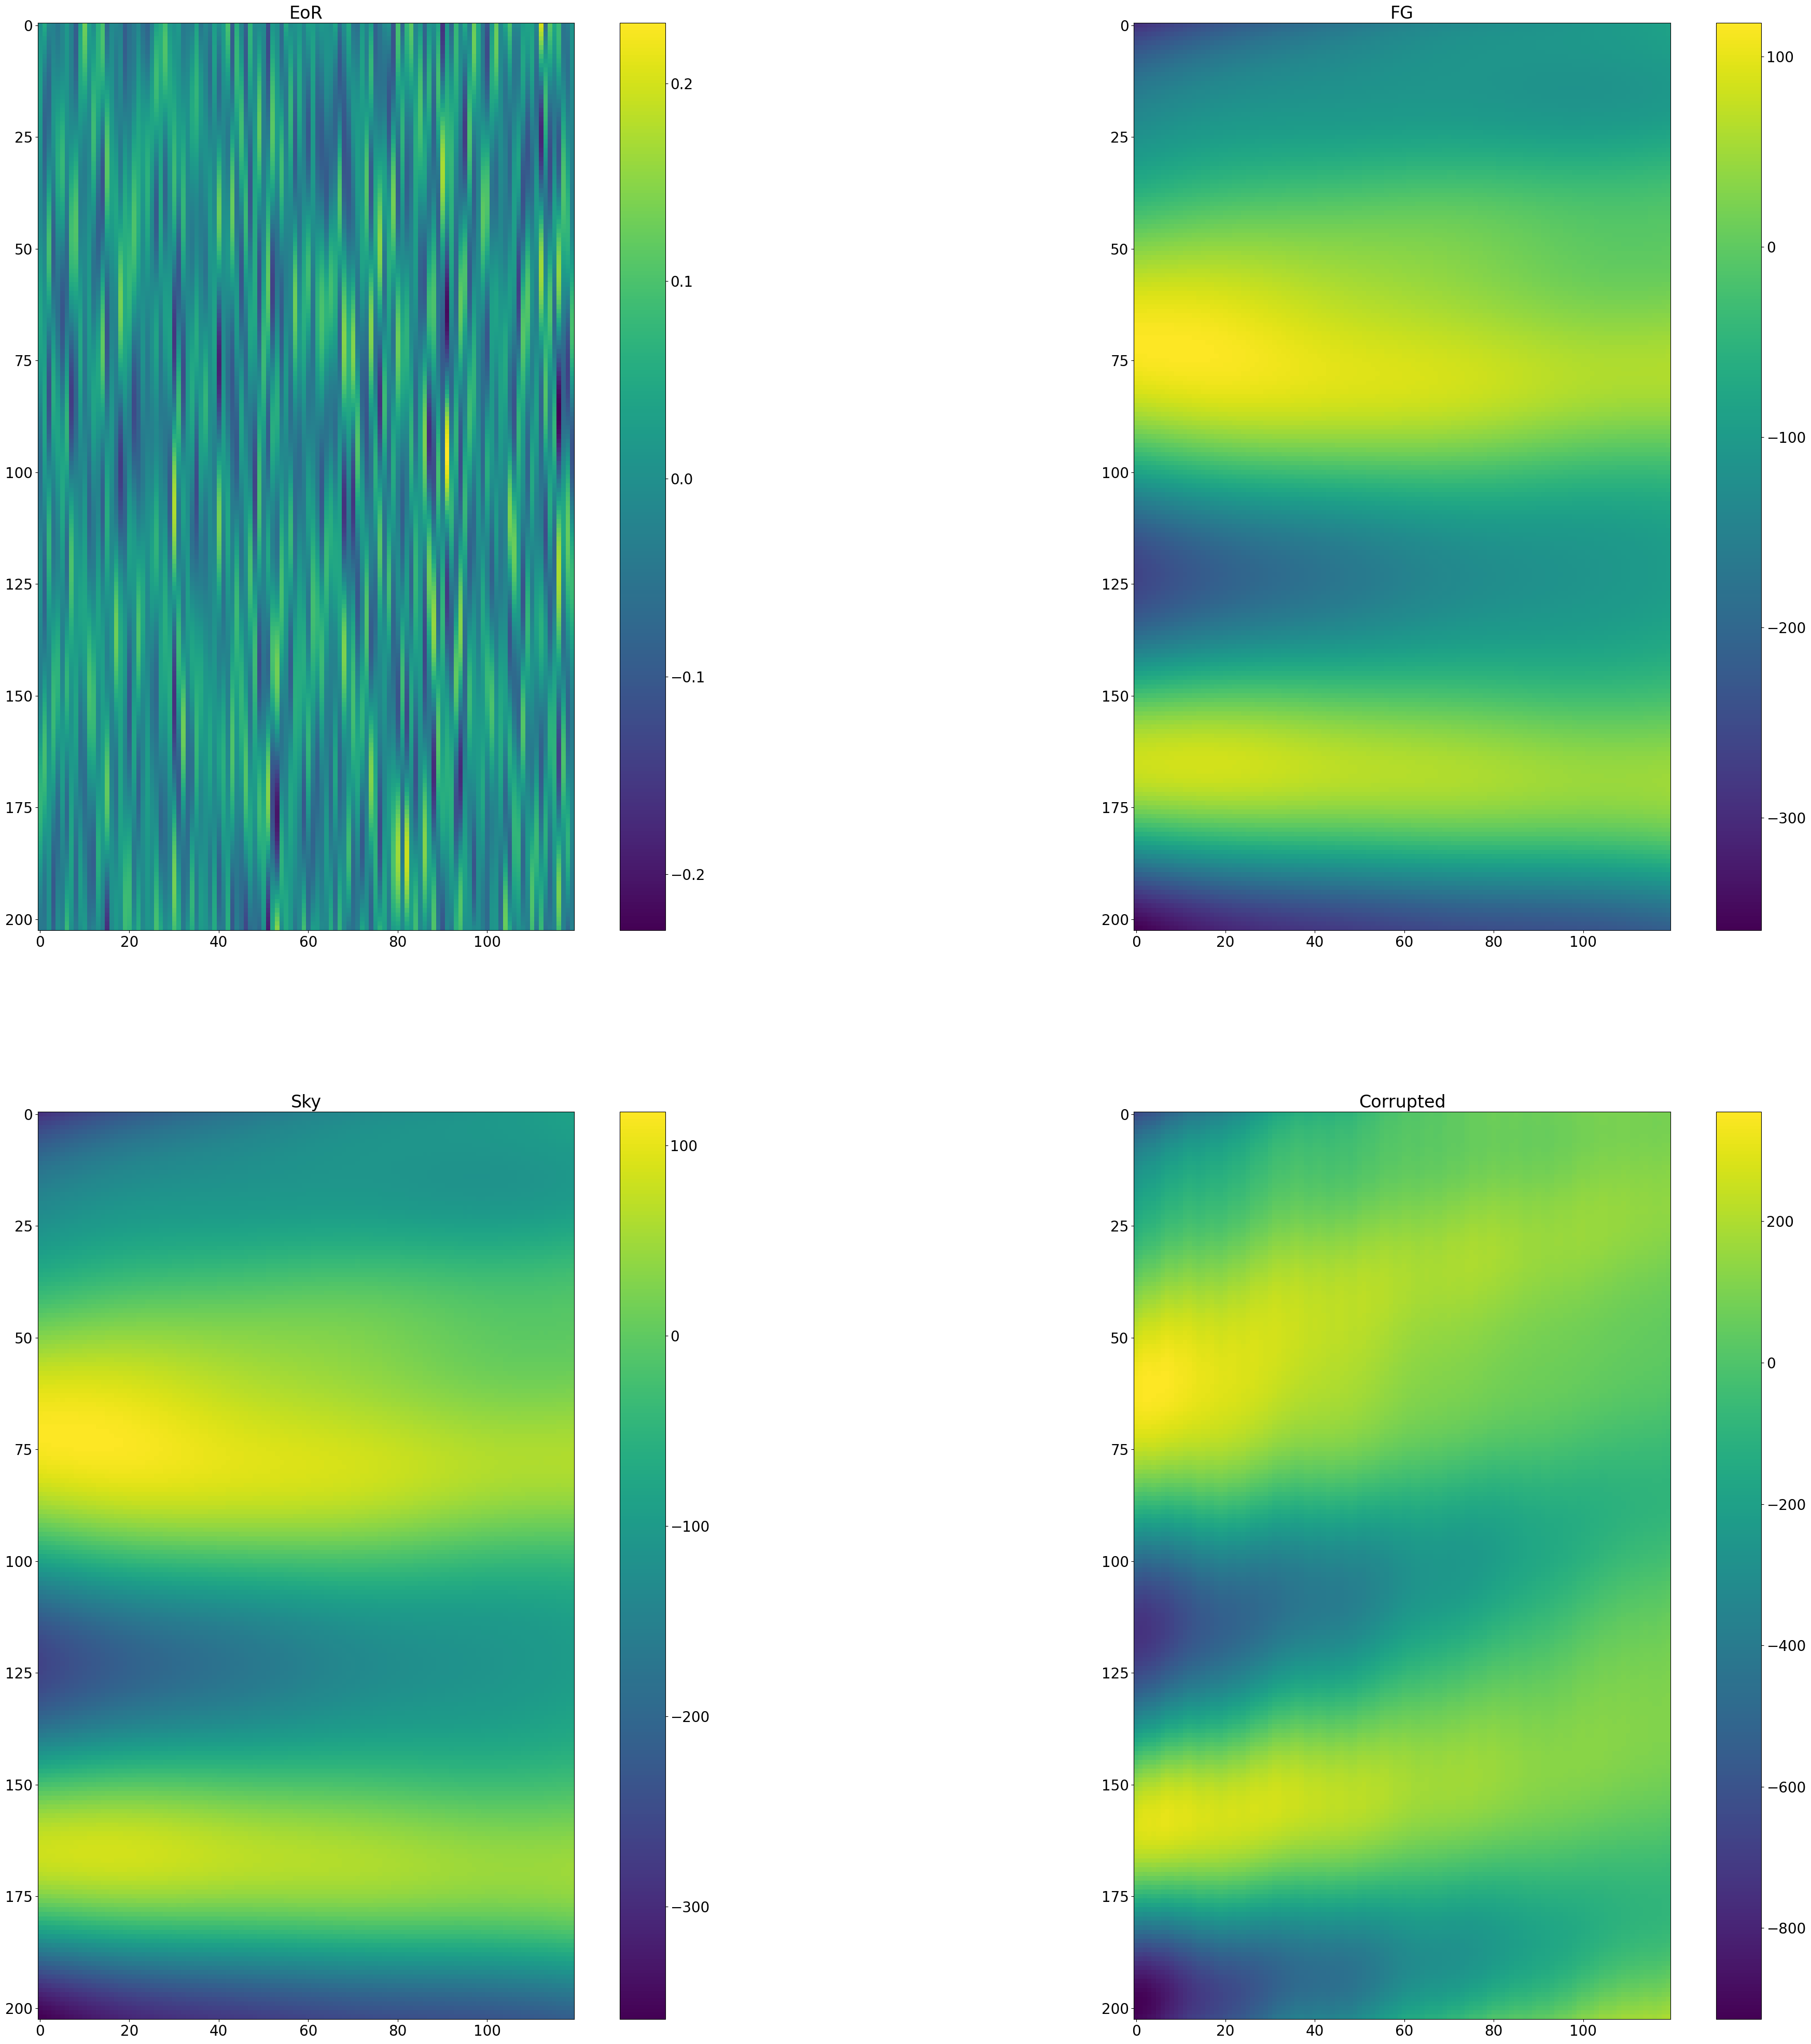

In [10]:
'''Plotting pre saved data'''
fig,axs=plt.subplots(2,2,figsize=(50,50))
data_uvh5_arr = [eor,fg,sky_uvh5,corr_uvh5]
fig_titles = ['EoR','FG','Sky','Corrupted']
i=0
for a in axs.flatten():
    im=a.imshow(data_uvh5_arr[i].real)
    plt.colorbar(im)
    a.set_title(fig_titles[i])
    i=i+1

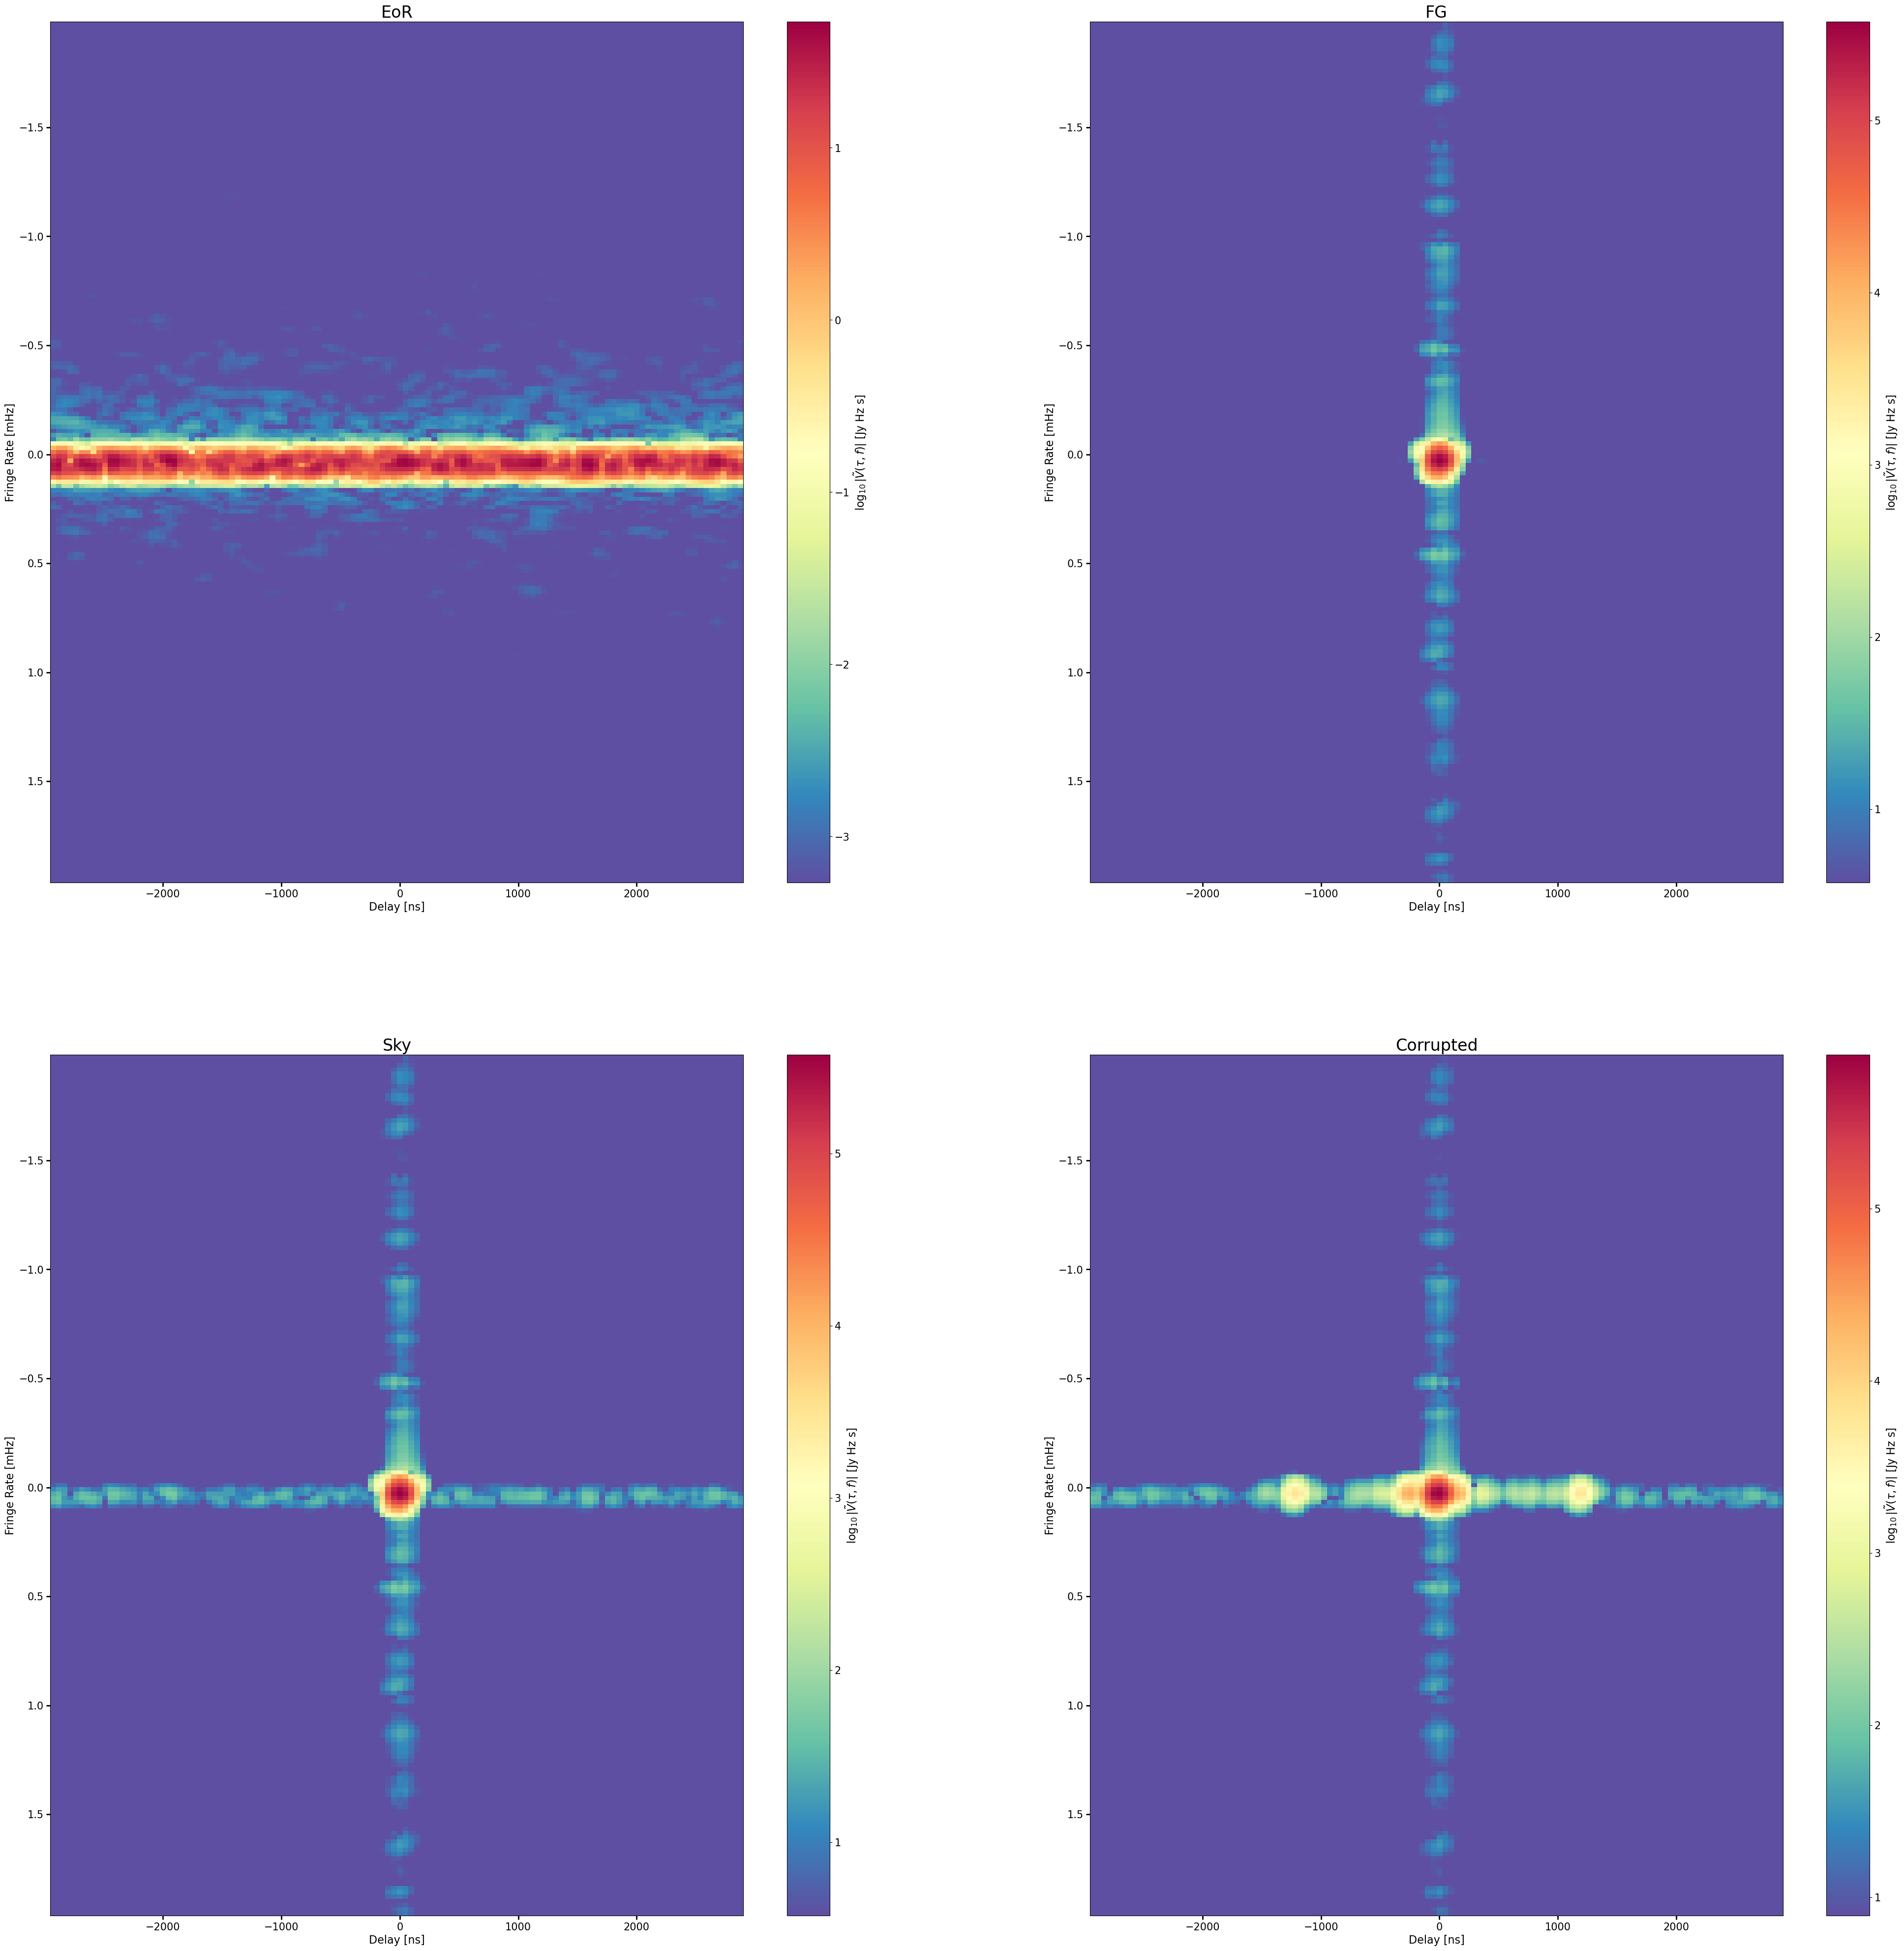

In [29]:
'''Plotting data in dl fr space'''
fig,axs=plt.subplots(2,2,figsize=(50,50))
data_uvh5_arr = [eor,fg,sky_uvh5,corr_uvh5]
fig_titles = ['EoR','FG','Sky','Corrupted']
i=0
dlfr_dict = dict()
for a in axs.flatten():
    _,dlfr_dict[fig_titles[i]]=plot_waterfalls(data_uvh5_arr[i], freqs, lsts, windows='blackman-harris', fig=fig,ax=a, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',
                freq_window_kwargs=None, time_window_kwargs=None)
    a.set_title(fig_titles[i])
    i=i+1

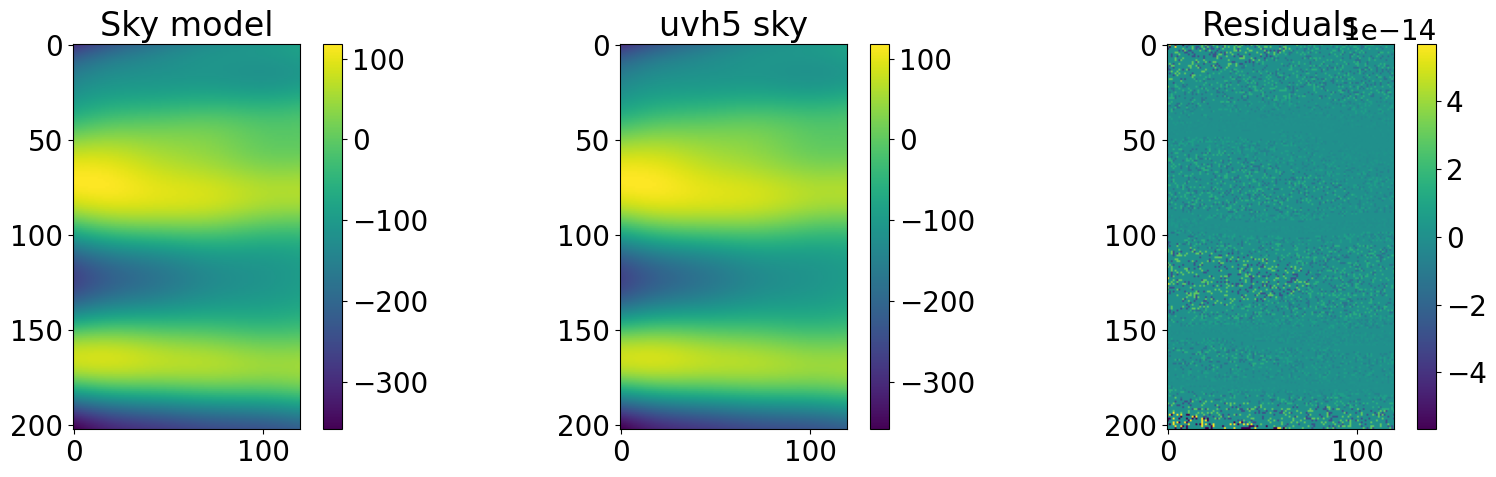

In [15]:
'''Checking if sky model holds up'''
sky_model =eor+fg

data_arr = [sky_model,sky_uvh5,sky_uvh5  - sky_model]
fig_titles = ['Sky model','uvh5 sky','Residuals']
fig,axs = plt.subplots(1,3,figsize=(20,5))
i=0

for a in axs.flatten():
    im=a.imshow(data_arr[i].real)
    plt.colorbar(im)
    a.set_title(fig_titles[i])
    i=i+1

divide by zero encountered in log10
divide by zero encountered in log10


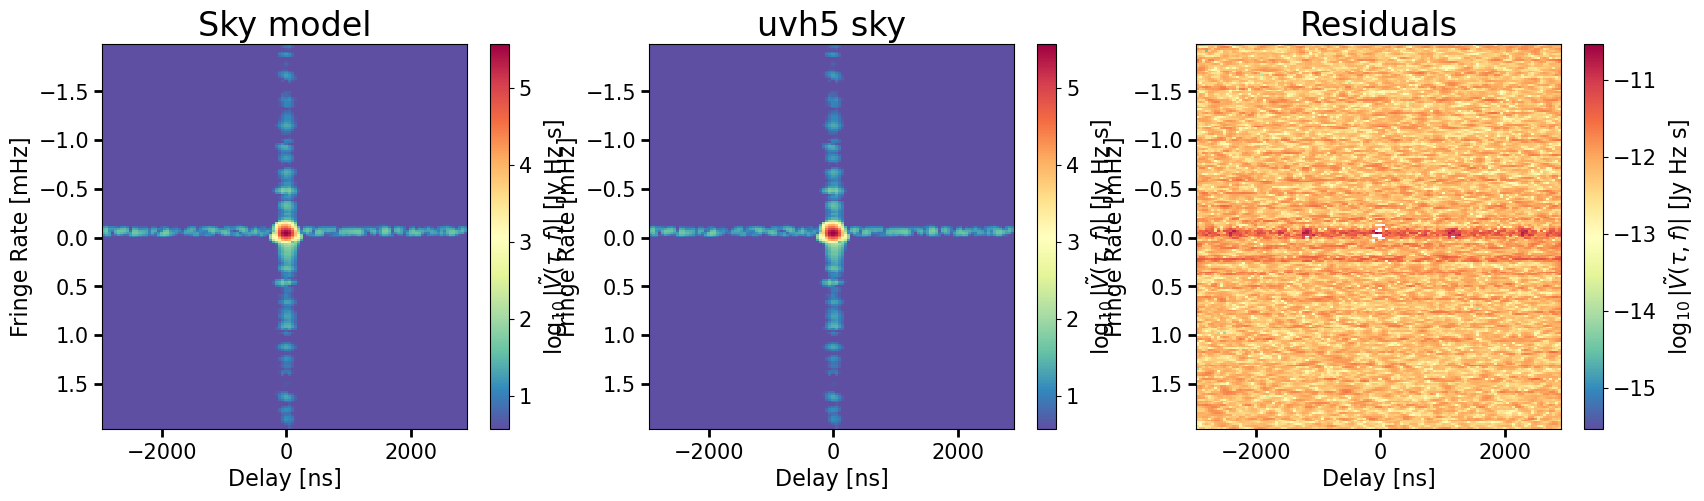

In [21]:
'''Checking sky model in dl fr space now'''

data_arr = [data_dly_fr(sky_model,freqs, lsts, windows='blackman-harris'),
            data_dly_fr(sky_uvh5,freqs, lsts, windows='blackman-harris'),
            data_dly_fr(sky_uvh5,freqs, lsts, windows='blackman-harris')  - data_dly_fr(sky_model,freqs, lsts, windows='blackman-harris')]
fig_titles = ['Sky model','uvh5 sky','Residuals']
fig,axs = plt.subplots(1,3,figsize=(20,5))
i=0

for a in axs.flatten():
    _=plot_waterfalls_from_dlfr(data_arr[i], freqs, lsts, fig=fig,ax=a, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
    a.set_title(fig_titles[i])
    i=i+1

In [22]:
'''Saving sky vis now'''
np.save(data_dir+'sky_true.npy',sky_uvh5)

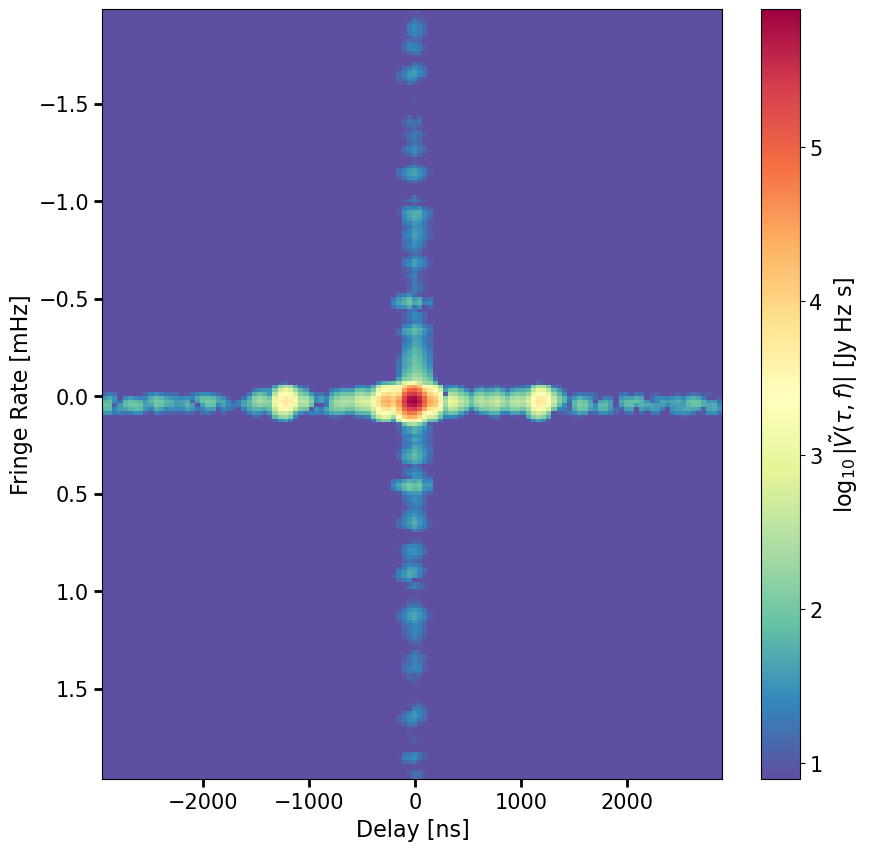

In [46]:
'''Finding modes now'''
# fig,axs=plt.subplots(1,2,figsize=(30,10))
_=plot_waterfalls(corr_uvh5, freqs, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',
                freq_window_kwargs=None, time_window_kwargs=None)

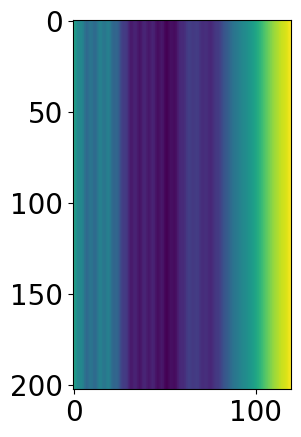

In [71]:
plt.imshow(((corr_uvh5/sky_uvh5) - 1).imag)

-25 0
-26 0
-27 0
-28 0
-25 0
26 0
27 0
28 0


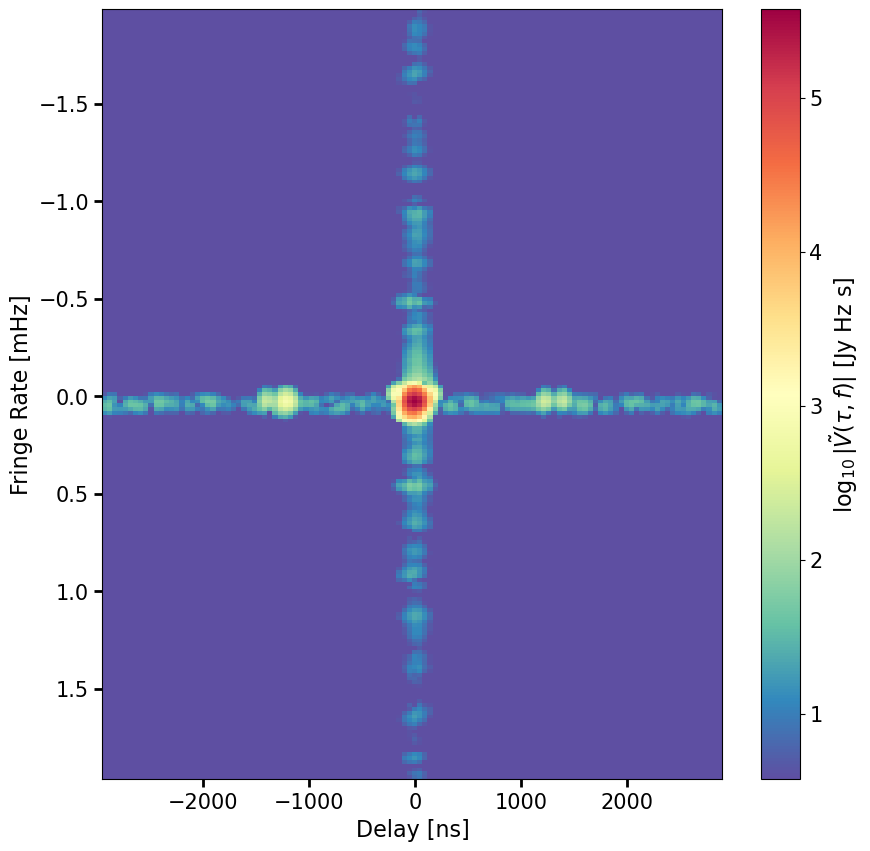

In [68]:
nm_list = [(-25,0),(-26,0),(-27,0),(-28,0),(-25,0),(26,0),(27,0),(28,0)] #low dl fr 0
sys_modes_operator = sys_modes(freqs_Hz=freqs*1e6, 
                                    times_sec=lsts * 24./(2.*np.pi) * 3600., 
                                    modes=nm_list)
sys_amps_true = 0.05*np.array([4. + 1j, 4.1 + 1j, 5. + 1j, 4. + 1j,4. + 1j, 4.1 + 1j, 5. + 1j, 4. + 1j]) #np.array([4., 4.01])
gain = (1. + (sys_modes_operator @ sys_amps_true).reshape([len(freqs),len(lsts)]).T)

test_vis = gain * sky_uvh5

_,dlfr_test=plot_waterfalls(test_vis, freqs, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',
                freq_window_kwargs=None, time_window_kwargs=None)

In [73]:
A = sys_modes_operator   # (60, 10)
B = ((corr_uvh5/sky_uvh5) - 1).flatten(order='F')               # (60, 80)

# Works for real or complex
X_hat, *_ = np.linalg.lstsq(A, B, rcond=None)  # X_hat: (10, 80)
sys_amps_fit = X_hat

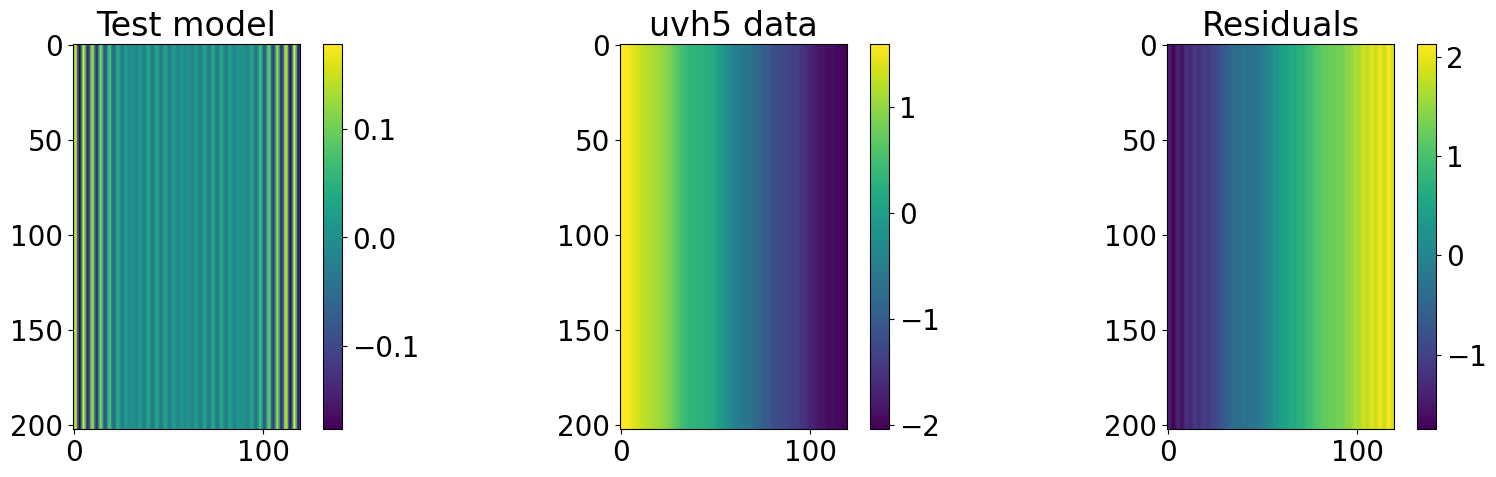

In [78]:
'''Checking if sky model holds up'''
gain_fit = (sys_modes_operator @ sys_amps_fit).reshape([len(freqs),len(lsts)]).T

gain_true = ((corr_uvh5/sky_uvh5) - 1)

data_arr = [gain_fit,gain_true,gain_fit  - gain_true]
fig_titles = ['Test model','uvh5 data','Residuals']
fig,axs = plt.subplots(1,3,figsize=(20,5))
i=0

for a in axs.flatten():
    im=a.imshow(data_arr[i].real)
    plt.colorbar(im)
    a.set_title(fig_titles[i])
    i=i+1

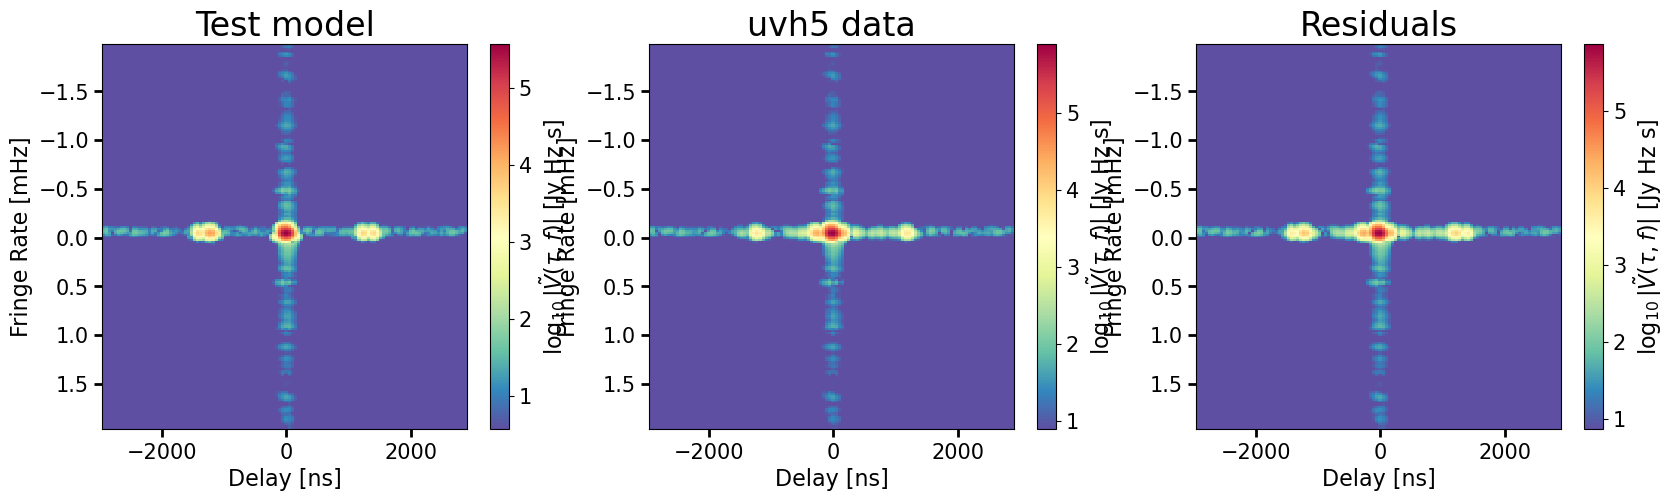

In [58]:
'''Checking sky model in dl fr space now'''

data_arr = [data_dly_fr(test_vis,freqs, lsts, windows='blackman-harris'),
            data_dly_fr(corr_uvh5,freqs, lsts, windows='blackman-harris'),
            data_dly_fr(corr_uvh5,freqs, lsts, windows='blackman-harris')  - data_dly_fr(test_vis,freqs, lsts, windows='blackman-harris')]
fig_titles = ['Test model','uvh5 data','Residuals']
fig,axs = plt.subplots(1,3,figsize=(20,5))
i=0

for a in axs.flatten():
    _=plot_waterfalls_from_dlfr(data_arr[i], freqs, lsts, fig=fig,ax=a, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
    a.set_title(fig_titles[i])
    i=i+1

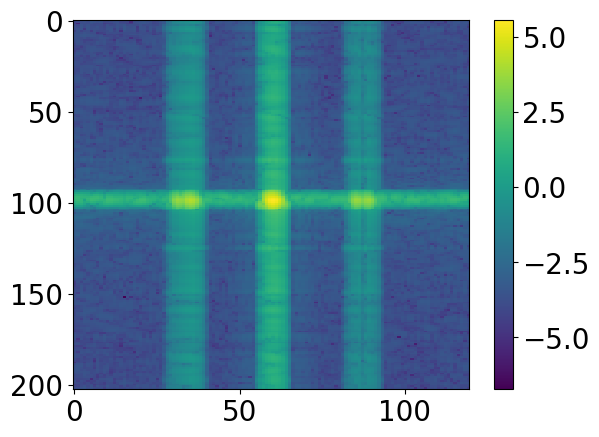

In [57]:
waterfall((dlfr_test))
plt.colorbar()